## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Grid_Optimization"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lamda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lamda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_relm_cv  = ArtificialBeeColonyElmCV(
    feature_size= features_size,
    hidden_size         = best_lamda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lamda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_relm_cv.employed_bee_apply_algo2()
abc_relm_cv.onlooker_bee_apply_algo3()

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_relm_cv, x_train, y_train, x_test, y_test)
results_df.describe()

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.770312,0.774292,0.764583,0.770741,0.776042,0.767878,0.765542,0.770312,0.542814,55.500000
std,0.042475,0.041582,0.071888,0.057862,0.048609,0.047063,0.060828,0.042475,0.085730,8.803408
min,0.687500,0.696970,0.656250,0.676471,0.687500,0.677419,0.664557,0.687500,0.375735,41.000000
25%,0.750000,0.743952,0.718750,0.735294,0.750000,0.738462,0.727848,0.750000,0.500000,48.250000
50%,0.757812,0.769048,0.750000,0.757353,0.781250,0.757353,0.754747,0.757812,0.526732,55.500000
75%,0.796875,0.806452,0.812500,0.804839,0.812500,0.800000,0.804635,0.796875,0.594040,62.750000
max,0.859375,0.862069,0.906250,0.896552,0.875000,0.865672,0.889571,0.859375,0.721930,70.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_F1-Score.png


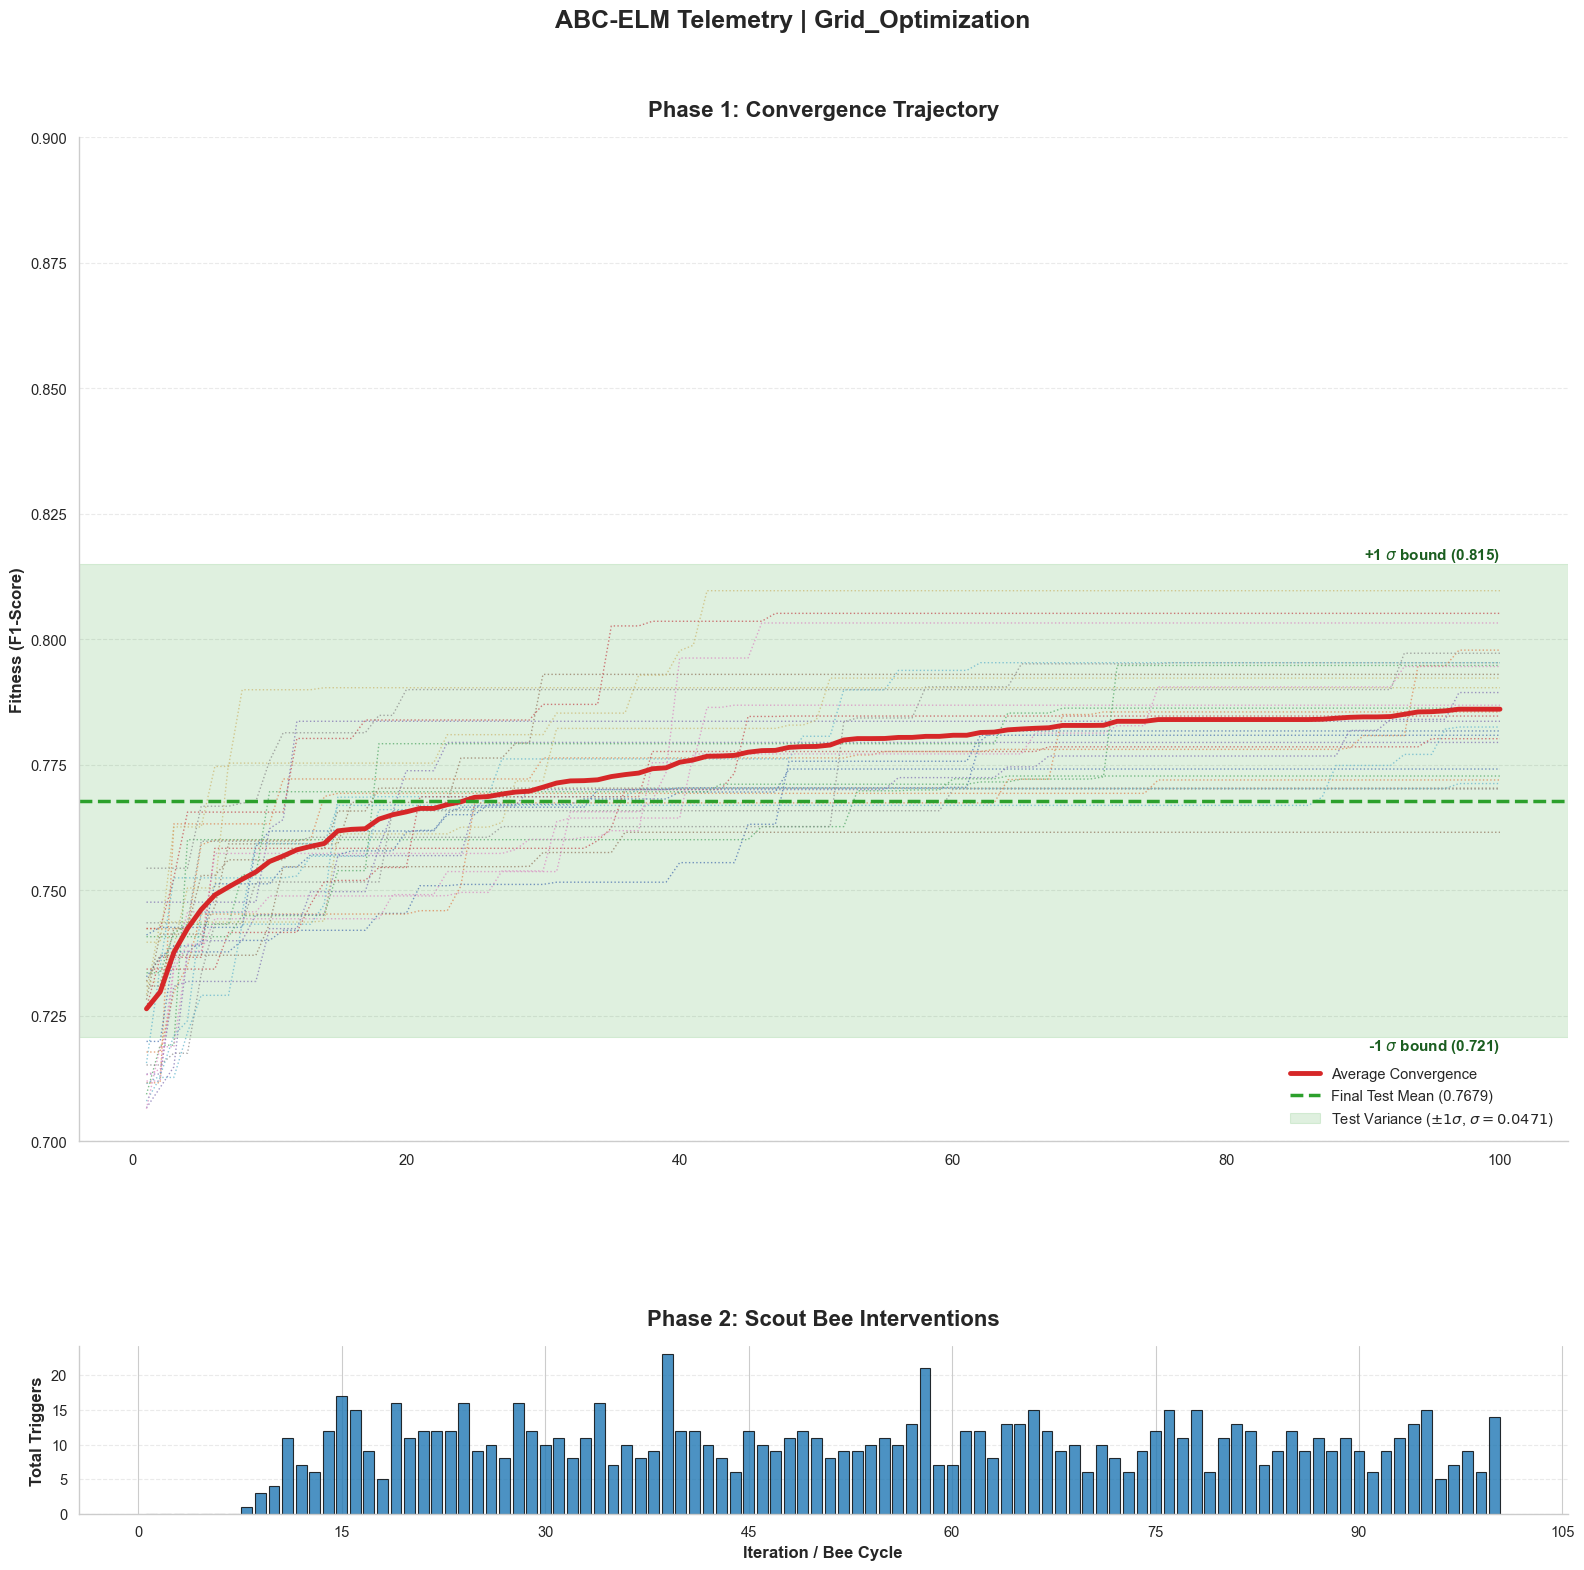

In [7]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [8]:
# GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
# GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
# GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')